In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
!pip install numpy pandas scikit-learn matplotlib seaborn -q

import platform
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록)
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.0.2
pandas: 2.3.3


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 이번 달 주문 데이터 생성 — 자기완결적 스냅샷
# (지난 노드에서 다룬 오염 요소를 적당히 섞어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)
n = 1500

regions = np.random.choice(["서울", "경기", "부산", "인천", "대구"], n, p=[0.4, 0.25, 0.15, 0.1, 0.1])
membership = np.random.choice(["basic", "silver", "gold", "vip"], n, p=[0.5, 0.25, 0.15, 0.1])
channels = np.random.choice(["web", "app", "app ", "APP"], n, p=[0.5, 0.4, 0.05, 0.05])
categories = np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n)

prices = np.random.choice([9900, 19900, 29900, 49900, 89900, 129900, 249900], n,
                          p=[0.2, 0.25, 0.2, 0.15, 0.1, 0.06, 0.04])
quantities = np.random.choice([1, 1, 1, 2, 2, 3], n)
amount = (prices * quantities).astype(float)

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(35, 9, n).round().astype(int),
    "region": regions,
    "membership": membership,
    "channel": channels,
    "category": categories,
    "price": prices.astype(float),
    "quantity": quantities,
    "amount": amount,
})

# 오염 심기: 결측·이상치·표기 혼재
orders.loc[np.random.choice(n, 60, replace=False), "amount"] = np.nan
orders.loc[np.random.choice(n, 30, replace=False), "customer_age"] = np.nan
orders.loc[5, "customer_age"] = 999             # 입력 실수성 이상치
orders.loc[8, "customer_age"] = -3              # 불가능한 음수
orders.loc[12, "quantity"] = 80                 # 비정상적으로 큰 주문
orders.loc[20, "region"] = " 서울 "             # 앞뒤 공백
orders.loc[21, "region"] = "Seoul"              # 영문 표기
orders.loc[40, "membership"] = "VIP"            # 대소문자 혼재

print("이번 달 주문 데이터 준비 완료:", orders.shape)
orders.head()

이번 달 주문 데이터 준비 완료: (1500, 9)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount
0,O00001,30.0,서울,silver,app,패션,19900.0,1,NaN
1,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0
2,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0
3,O00004,24.0,경기,basic,app,뷰티,19900.0,1,NaN
4,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0


In [3]:
# 예제: 같은 결과를 세 가지 방법으로 — 'amount'에 부가세 10% 더하기
amounts = orders["amount"].dropna().head(8)
print("원본:", amounts.tolist())

# (a) apply: 사용자 정의 함수 적용
def add_vat(x):
    return x * 1.1

by_apply = amounts.apply(add_vat)

# (b) map: 함수도 받지만, dict로 치환할 때 더 자연스러움
by_map = amounts.map(add_vat)

# (c) 벡터화: 함수 없이 연산자 하나
by_vec = amounts * 1.1

print("apply 결과:", by_apply.round(0).tolist())
print("map   결과:", by_map.round(0).tolist())
print("벡터화 결과:", by_vec.round(0).tolist())

원본: [749700.0, 19900.0, 19900.0, 29900.0, 59700.0, 389700.0, 19900.0, 89900.0]
apply 결과: [824670.0, 21890.0, 21890.0, 32890.0, 65670.0, 428670.0, 21890.0, 98890.0]
map   결과: [824670.0, 21890.0, 21890.0, 32890.0, 65670.0, 428670.0, 21890.0, 98890.0]
벡터화 결과: [824670.0, 21890.0, 21890.0, 32890.0, 65670.0, 428670.0, 21890.0, 98890.0]


In [4]:
# 예제: 'map'이 가장 어울리는 자리 — dict 치환
gender_kr_to_num = {"M": 1, "F": 0}
sample_gender = pd.Series(["M", "F", "F", "M", "F"])

# map은 dict를 그대로 받습니다. 이게 가장 자연스러움.
print("map(dict):", sample_gender.map(gender_kr_to_num).tolist())

# 같은 일을 apply로 하려면 dict.get을 래핑해야 합니다(가독성 떨어짐).
print("apply(lambda):", sample_gender.apply(lambda x: gender_kr_to_num.get(x)).tolist())

map(dict): [1, 0, 0, 1, 0]
apply(lambda): [1, 0, 0, 1, 0]


In [5]:
# 예제: 속도 비교 — 10만 건에 '부가세 10% 더하기'
big = pd.Series(np.random.randint(1000, 100_000, 100_000).astype(float))

# (a) apply
start = time.time()
_ = big.apply(lambda x: x * 1.1)
t_apply = time.time() - start

# (b) map
start = time.time()
_ = big.map(lambda x: x * 1.1)
t_map = time.time() - start

# (c) 벡터화
start = time.time()
_ = big * 1.1
t_vec = time.time() - start

print(f"apply  : {t_apply*1000:.1f} ms")
print(f"map    : {t_map*1000:.1f} ms")
print(f"벡터화 : {t_vec*1000:.1f} ms")
print(f"→ 벡터화가 apply보다 약 {t_apply/max(t_vec, 1e-9):.0f}배 빠릅니다 (환경에 따라 다름)")

apply  : 17.4 ms
map    : 17.0 ms
벡터화 : 0.0 ms
→ 벡터화가 apply보다 약 17432451배 빠릅니다 (환경에 따라 다름)


In [6]:
# 예제: 모두마켓 데이터에 셋을 모두 적용 — '주문 등급' 만들기
# 규칙: amount >= 100000 → 'high', 30000 이상 → 'mid', 그 외 'low'

# (a) apply (행 단위 — 가독성은 좋지만 느림)
def classify(amount):
    if pd.isna(amount):
        return np.nan
    if amount >= 100_000:
        return "high"
    elif amount >= 30_000:
        return "mid"
    return "low"

orders["grade_apply"] = orders["amount"].apply(classify)

# (b) 벡터화 (np.select가 'if-elif-else'의 벡터화 버전)
orders["grade_vec"] = np.select(
    [orders["amount"] >= 100_000, orders["amount"] >= 30_000],
    ["high", "mid"],
    default="low"
)
# 결측은 결측으로 두기
orders.loc[orders["amount"].isna(), "grade_vec"] = np.nan

# 결과가 같은지 확인 (결측 처리도 함께)
print("두 방식 결과 동일?:", (orders["grade_apply"].fillna("X") == orders["grade_vec"].fillna("X")).all())
print(orders[["amount", "grade_apply", "grade_vec"]].head())

두 방식 결과 동일?: True
     amount grade_apply grade_vec
0       NaN         NaN       NaN
1  749700.0        high      high
2   19900.0         low       low
3       NaN         NaN       NaN
4   19900.0         low       low


In [7]:
# 스스로 해보자! (1)
# 아래 주석(#)을 지우고 빈칸(___)을 채운 뒤 실행해보세요.

weight = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
orders["membership_score"] = orders["membership"].map(weight)   # 1) map / apply 중 자연스러운 것은?
print(orders[["membership", "membership_score"]].head())

orders["age_next_year_apply"] = orders["customer_age"].apply(lambda x: x + 1)
orders["age_next_year_vec"]   = orders["customer_age"] + 1
print((orders["age_next_year_apply"] == orders["age_next_year_vec"]).all())
# NaN == NaN은 pandas/numpy에서 False로 평가되기 때문에, 그 행에서 비교 결과가 False가 됨.

  membership  membership_score
0     silver               2.0
1      basic               1.0
2      basic               1.0
3      basic               1.0
4      basic               1.0
False


1. 값을 다른 값으로 "치환/매핑"하는가? (예: 카테고리 코드 → 이름, dict나 Series로 룩업)
→ map 이 가장 자연스러움. Series.map({"M": "Male", "F": "Female"}) 처럼 대응표가 있을 때.
2. 각 원소(또는 행)마다 조건문·분기·복잡한 로직이 필요한가?
→ apply. numpy/pandas 연산만으로 표현 안 되는 커스텀 함수, 여러 컬럼을 동시에 참조하는 행 단위 로직(df.apply(..., axis=1)) 등.
3. 컬럼 전체에 동일한 산술/비교/논리 연산을 적용할 수 있는가?
→ 벡터화. orders["age"] + 1, orders["price"] * 1.1 처럼 numpy가 이미 지원하는 연산이면 무조건 이게 우선.
map VS apply
1. 적용 범위가 다릅니다.
map은 Series에만 있습니다. DataFrame에는 없어요(엄밀히는 최신 pandas에 DataFrame.map이 생겼지만 이건 element-wise 전용, 예전 applymap 대체).
apply는 Series와 DataFrame 둘 다 있고, DataFrame에서는 axis로 행 단위/열 단위 연산도 가능합니다.
2. map은 함수 외에 dict·Series 매핑도 받습니다.
apply는 함수만 받습니다.
그래서 실제 구분 기준은 이렇게 좁혀집니다.

Series 하나에 함수를 걸 뿐이라면 map과 apply는 사실상 동일하게 동작 (성능도 비슷). 이때는 관례상 "치환/룩업 느낌"이면 map, "커스텀 로직 적용" 느낌이면 apply를 씁니다.
행 전체(여러 컬럼)를 참조해야 하거나 DataFrame에 axis 지정이 필요하면 → apply만 가능.
dict나 다른 Series로 값을 대응시키는 거라면 → map이 더 직관적(굳이 함수로 안 짜도 됨).

▸apply, map, 벡터화 중 일반적으로 가장 빠른 것은 무엇인가요? 벡터화
▸dict로 "이 값을 저 값으로" 치환할 때 가장 자연스러운 도구는 무엇인가요? map
▸if-elif-else 분기를 벡터화하려면 어떤 함수를 떠올릴 수 있나요? select

In [8]:
# 예제: 세 가지 스케일러를 직접 비교 — 'amount'에 적용
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

amt = orders[["amount"]].dropna()   # 2D로 두는 게 sklearn 관례

mm = MinMaxScaler().fit_transform(amt)
ss = StandardScaler().fit_transform(amt)
rs = RobustScaler().fit_transform(amt)

scaled = pd.DataFrame({
    "original": amt["amount"].values,
    "minmax":   mm.flatten(),
    "standard": ss.flatten(),
    "robust":   rs.flatten(),
})
print(scaled.describe().round(2))

        original   minmax  standard   robust
count    1440.00  1440.00   1440.00  1440.00
mean    75532.57     0.09      0.00     0.51
std     95960.56     0.13      1.00     1.37
min      9900.00     0.00     -0.68    -0.43
25%     19900.00     0.01     -0.58    -0.28
50%     39800.00     0.04     -0.37     0.00
75%     89900.00     0.11      0.15     0.72
max    749700.00     1.00      7.03    10.14


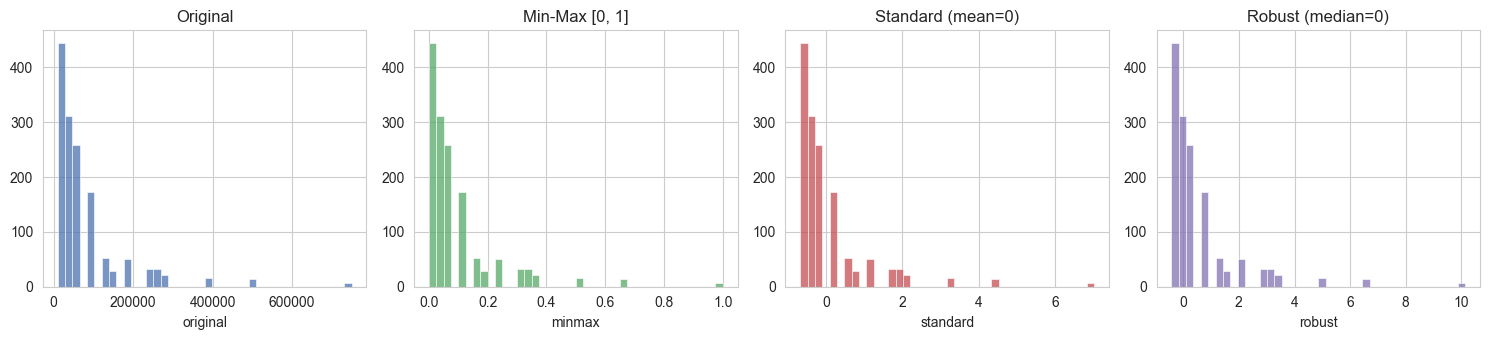

In [9]:
# 예제: 그림으로 비교 — 이상치가 있을 때 각 스케일러가 어떻게 반응하나
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
sns.histplot(scaled["original"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Original")

sns.histplot(scaled["minmax"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Min-Max [0, 1]")

sns.histplot(scaled["standard"], bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Standard (mean=0)")

sns.histplot(scaled["robust"], bins=40, ax=axes[3], color="#8172B2")
axes[3].set_title("Robust (median=0)")

for ax in axes:
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

 같은 이상치인데 robust에서 훨씬 더 멀리 밀려나 있다

In [10]:
# 예제: fit / transform 분리 — 실서비스의 정석
# 학습 데이터로 'fit'한 통계량을 새 데이터에도 똑같이 'transform'에 써야 합니다.
train = orders.iloc[:1000][["amount"]].dropna()
test  = orders.iloc[1000:][["amount"]].dropna()

scaler = StandardScaler()
scaler.fit(train)                              # train의 평균·표준편차를 기억
train_scaled = scaler.transform(train)         # 같은 기준으로 변환
test_scaled  = scaler.transform(test)          # test에도 같은 기준 적용

print("train 평균:", round(train_scaled.mean(), 3), "표준편차:", round(train_scaled.std(), 3))
print("test  평균:", round(test_scaled.mean(), 3),  "표준편차:", round(test_scaled.std(), 3))

train 평균: -0.0 표준편차: 1.0
test  평균: -0.022 표준편차: 0.922


train이든 test든 상관없이 항상 train에서 저장된 기준을 씁니다.

왜 이렇게 해야 하나요?
실서비스에서는 미래에 들어올 데이터(test/운영 데이터)의 평균·표준편차를 미리 알 수 없습니다. 만약 test에도 fit을 따로 하면, 모델이 학습 시점에 알 수 없어야 할 미래 데이터의 정보를 몰래 엿보는 셈이 됩니다 (data leakage). 그래서 "fit은 train에만, transform은 둘 다에" 라는 원칙을 지킵니다.

그래서 결과가 이렇게 나옵니다.
train_scaled: 평균 0, 표준편차 1에 거의 정확히 맞음 (당연함, train 자신의 평균·표준편차로 변환했으니까)
test_scaled: 평균과 표준편차가 0, 1에서 살짝 벗어남 (test 데이터를 test 자신의 통계량이 아니라 train의 통계량으로 변환했기 때문)

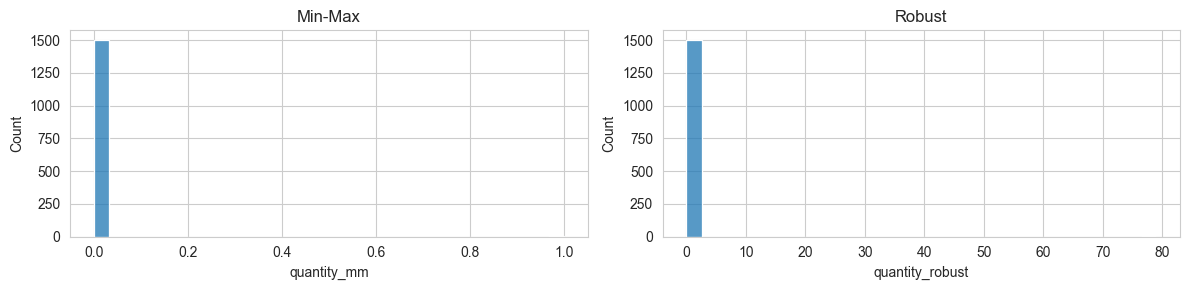

In [11]:
# 스스로 해보자! (3)
from sklearn.preprocessing import MinMaxScaler, RobustScaler

qty = orders[["quantity"]]
orders["quantity_mm"]     = MinMaxScaler().fit_transform(qty)
orders["quantity_robust"] = RobustScaler().fit_transform(qty)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.histplot(orders["quantity_mm"],     bins=30, ax=axes[0]); axes[0].set_title("Min-Max")
sns.histplot(orders["quantity_robust"], bins=30, ax=axes[1]); axes[1].set_title("Robust")
plt.tight_layout(); plt.show()

▸Min-Max·Standard·Robust의 분모(나눠지는 양)는 각각 무엇인가요?
Min-Max: max - min (범위)
Standard: 표준편차(std)
Robust: IQR = Q3 - Q1 (사분위 범위)

▸이상치가 의심될 때 가장 안전한 기본값은 무엇인가요? robust

▸fit을 학습 데이터에만 적용해야 하는 이유는 무엇인가요? 
test에 fit하면 미래 정보를 학습 때 미리 훔쳐보는 data leakage가 생기기 때문.

method chaining : 여러 개의 pandas 메서드를 . 으로 연속해서 이어 붙여, 중간 변수 없이 한 번에 처리하는 스타일. (df.dropna().filter().assign().sort_values()처럼)

In [12]:
# 예제: '단계 변수'로 쓴 정제와 'chaining'으로 쓴 정제 — 결과는 같음

# (a) 단계 변수 방식 (전통)
step1 = orders.dropna(subset=["amount", "customer_age"])
step2 = step1[(step1["customer_age"] > 0) & (step1["customer_age"] < 120)]
step3 = step2.assign(
    region_clean=step2["region"].str.strip().replace({"Seoul": "서울"}),
    amount_log=np.log1p(step2["amount"]),
)
clean_a = step3.sort_values("amount", ascending=False).reset_index(drop=True)

# (b) method chaining 방식 (체이닝)
clean_b = (
    orders
    .dropna(subset=["amount", "customer_age"])
    .query("0 < customer_age < 120")
    .assign(
        region_clean=lambda d: d["region"].str.strip().replace({"Seoul": "서울"}),
        amount_log=lambda d: np.log1p(d["amount"]),
    )
    .sort_values("amount", ascending=False)
    .reset_index(drop=True)
)

# 두 결과가 같은가?
print("두 방식 결과 동일?:", clean_a.equals(clean_b))
print("정제 후 행 수:", clean_b.shape[0])
clean_b.head(3)

두 방식 결과 동일?: True
정제 후 행 수: 1411


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,grade_apply,grade_vec,membership_score,age_next_year_apply,age_next_year_vec,quantity_mm,quantity_robust,region_clean,amount_log
0,O00659,33.0,경기,basic,app,도서,249900.0,3,749700.0,high,high,1.0,34.0,34.0,0.025316,2.0,경기,13.52743
1,O00096,39.0,경기,silver,app,뷰티,249900.0,3,749700.0,high,high,2.0,40.0,40.0,0.025316,2.0,경기,13.52743
2,O00531,49.0,인천,basic,web,가전,249900.0,3,749700.0,high,high,1.0,50.0,50.0,0.025316,2.0,인천,13.52743


In [13]:
# 예제: query로 같은 필터 작성
# 1) 전통 방식
cond = (orders["customer_age"] > 0) & (orders["customer_age"] < 120) & (orders["amount"] >= 30000)
trad = orders[cond]

# 2) query 방식
q = orders.query("0 < customer_age < 120 and amount >= 30000")

print("동일?", trad.equals(q))
print("건수:", len(q))

동일? True
건수: 776


In [14]:
# 스스로 해보자! (4)
# 아래 빈칸(___)을 채우고 실행해보세요.

result = (
    orders
    .dropna(subset=["amount"])
    .query("0 < customer_age < 120")
    .assign(
        channel_clean=lambda d: d["channel"].str.strip().str.replace({"Seoul": "서울"}),
        amount_log=lambda d: np.log1p(d["amount"]),
    )
    .sort_values("amount", ascending=False)
    .reset_index(drop=True)
)
print(result.shape)
result.head(3)

TypeError: replace() missing 1 required positional argument: 'repl'

In [15]:
# 예제: 단계마다 함수로 빼기 — '한 함수 = 한 책임'
def clean_strings(df):
    # 공백·대소문자·표기 혼재를 정리합니다.
    return df.assign(
        region=df["region"].str.strip().replace({"Seoul": "서울"}),
        membership=df["membership"].str.lower(),
        channel=df["channel"].str.strip().str.lower(),
    )

def drop_invalid(df, age_min=0, age_max=120, qty_max=20):
    # 불가능한 값(나이 범위·과대 수량)과 결측을 제거합니다.
    return (
        df
        .dropna(subset=["amount", "customer_age"])
        .query("@age_min < customer_age < @age_max")
        .query("quantity <= @qty_max")
    )

def add_features(df):
    # 분석에 쓸 파생 컬럼을 추가합니다.
    return df.assign(
        amount_log=lambda d: np.log1p(d["amount"]),
        is_premium=lambda d: d["membership"].isin(["gold", "vip"]).astype(int),
    )

print("세 함수가 준비됐습니다. 다음 셀에서 한 줄로 조립합니다.")

세 함수가 준비됐습니다. 다음 셀에서 한 줄로 조립합니다.


In [16]:
# 예제: 한 줄로 조립
cleaned = (
    orders
    .pipe(clean_strings)
    .pipe(drop_invalid, age_min=10, age_max=80, qty_max=10)
    .pipe(add_features)
)

print("원본:", orders.shape, "→ 정제 후:", cleaned.shape)
cleaned.head(3)

원본: (1500, 16) → 정제 후: (1404, 18)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,grade_apply,grade_vec,membership_score,age_next_year_apply,age_next_year_vec,quantity_mm,quantity_robust,amount_log,is_premium
1,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0,high,high,1.0,25.0,25.0,0.025316,2.0,13.527430,0
2,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0,low,low,1.0,46.0,46.0,0.000000,0.0,9.898525,0
4,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0,low,low,1.0,42.0,42.0,0.000000,0.0,9.898525,0


In [17]:
# 예제: 인코딩/스케일링 함수 추가
from sklearn.preprocessing import RobustScaler

def encode_categories(df):
    # membership은 Ordinal, region·channel·category는 One-Hot.
    order_map = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
    out = df.assign(membership_ord=df["membership"].map(order_map))
    # One-Hot
    out = pd.concat(
        [out,
         pd.get_dummies(out["region"], prefix="region", dtype=int),
         pd.get_dummies(out["channel"], prefix="ch", dtype=int),
         pd.get_dummies(out["category"], prefix="cat", dtype=int)],
        axis=1
    )
    return out

def scale_numeric(df, cols=("customer_age", "amount", "quantity")):
    # 수치형 컬럼을 RobustScaler로 스케일링.
    scaler = RobustScaler()
    scaled = scaler.fit_transform(df[list(cols)])
    scaled_df = pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in cols], index=df.index)
    return pd.concat([df, scaled_df], axis=1)

# 전체 파이프라인 한 줄
pipeline_result = (
    orders
    .pipe(clean_strings)
    .pipe(drop_invalid, age_min=10, age_max=80, qty_max=10)
    .pipe(add_features)
    .pipe(encode_categories)
    .pipe(scale_numeric)
)

print("최종 shape:", pipeline_result.shape)
print("새로 생긴 컬럼 일부:", [c for c in pipeline_result.columns if "scaled" in c or c.startswith("region_")][:8])

최종 shape: (1404, 34)
새로 생긴 컬럼 일부: ['region_경기', 'region_대구', 'region_부산', 'region_서울', 'region_인천', 'customer_age_scaled', 'amount_scaled', 'quantity_scaled']


In [18]:
def add_amount_class(df):
    return df.assign(amount_class=np.where(df["amount"] >= 100_000, "high", "low"))

orders_v2 = (
    orders
    .pipe(clean_strings)
    .pipe(drop_invalid)
    .pipe(add_features)
    .pipe(add_amount_class)
)

print(orders_v2[["amount", "amount_class"]].head())
print(orders_v2["amount_class"].value_counts())


     amount amount_class
1  749700.0         high
2   19900.0          low
4   19900.0          low
6   59700.0          low
7  389700.0         high
amount_class
low     1162
high     248
Name: count, dtype: int64


내장 메서드 체이닝 : pandas가 이미 제공하는 기능들 연결

pipe = 내가 만든 함수(여러 줄짜리 로직, 여러 컬럼 처리 등)도 같은 체이닝 스타일로 자연스럽게 끼워 넣기

같은 흐름을 함수가 아닌 chaining만으로 작성하면 어떤 점이 불편해질까요?

같은 로직을 다른 데이터에 재사용하려면 코드를 통째로 복붙해야 하고, 

유지보수(수정) 시 여러 곳을 동시에 고쳐야 하는 게 불편함

▸df.pipe(func)와 func(df)의 결과는 같습니다. 그런데도 pipe를 쓰는 이유는 무엇인가요? 내장 메서드 체이닝(.dropna().assign()...)과 같은 스타일로, 커스텀 함수도 끊김 없이 자연스럽게 이어 쓸 수 있게 하기 위함

▸파이프에 끼울 함수가 지켜야 할 약속은 무엇인가요? (입력·출력) 첫 입력은 DataFrame, 반환도 DataFrame.

▸같은 흐름을 다음 달 데이터에 다시 적용해야 할 때, chaining-only와 .pipe(함수) 중 어느 쪽이 유리한가요? .pipe

In [19]:
# ─────────────────────────────────────────────
# 시나리오 0 — 원본 CSV 파일 준비 (실무에서는 외부에서 받아오는 단계)
# ─────────────────────────────────────────────
work_dir = Path("d006_work")
work_dir.mkdir(exist_ok=True)
input_csv  = work_dir / "orders_raw.csv"
output_csv = work_dir / "orders_clean.csv"

orders.to_csv(input_csv, index=False)
print("원본 CSV 저장:", input_csv, "—", input_csv.stat().st_size, "bytes")

원본 CSV 저장: d006_work\orders_raw.csv — 138889 bytes


In [20]:
# 시나리오 1 — 단계 함수들
def load_orders(path):
    # CSV에서 주문 데이터를 읽어 옵니다.
    return pd.read_csv(path)

def clean_strings_full(df):
    # 문자열 컬럼의 공백·대소문자·표기 혼재를 정리합니다.
    return df.assign(
        region=df["region"].str.strip().replace({"Seoul": "서울"}),
        membership=df["membership"].str.lower(),
        channel=df["channel"].str.strip().str.lower(),
    )

def drop_invalid_rows(df, age_min=10, age_max=80, qty_max=10):
    # 불가능한 값과 결측을 제거합니다.
    return (
        df
        .dropna(subset=["amount", "customer_age"])
        .query("@age_min < customer_age < @age_max")
        .query("quantity <= @qty_max")
        .drop_duplicates()
        .reset_index(drop=True)
    )

def add_derived(df):
    # 분석용 파생 컬럼을 추가합니다.
    return df.assign(
        amount_log=lambda d: np.log1p(d["amount"]),
        is_premium=lambda d: d["membership"].isin(["gold", "vip"]).astype(int),
        amount_class=lambda d: np.where(d["amount"] >= 100_000, "high",
                                np.where(d["amount"] >= 30_000, "mid", "low"))
    )

def encode_full(df):
    # membership=Ordinal, 나머지=One-Hot.
    order_map = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
    out = df.assign(membership_ord=df["membership"].map(order_map))
    one_hots = [
        pd.get_dummies(out["region"],   prefix="region", dtype=int),
        pd.get_dummies(out["channel"],  prefix="ch",     dtype=int),
        pd.get_dummies(out["category"], prefix="cat",    dtype=int),
    ]
    return pd.concat([out] + one_hots, axis=1)

def scale_with_robust(df, cols=("customer_age", "amount", "quantity")):
    # 수치형 컬럼을 Robust로 스케일링하고 _scaled 접미사를 붙입니다.
    scaler = RobustScaler()
    scaled = scaler.fit_transform(df[list(cols)])
    scaled_df = pd.DataFrame(scaled,
                             columns=[f"{c}_scaled" for c in cols],
                             index=df.index)
    return pd.concat([df, scaled_df], axis=1)

print("단계 함수 6개 정의 완료. 다음 셀에서 한 줄로 조립합니다.")

단계 함수 6개 정의 완료. 다음 셀에서 한 줄로 조립합니다.


In [21]:
# 시나리오 2 — end-to-end 파이프라인
def preprocess(input_path):
    # 원본 CSV 경로를 받아 전처리된 DataFrame을 돌려줍니다.
    return (
        load_orders(input_path)
        .pipe(clean_strings_full)
        .pipe(drop_invalid_rows, age_min=10, age_max=80, qty_max=10)
        .pipe(add_derived)
        .pipe(encode_full)
        .pipe(scale_with_robust)
    )

# 진짜 한 줄 호출
clean_df = preprocess(input_csv)
print("입력 행 수 → 출력 행 수:", orders.shape[0], "→", clean_df.shape[0])
print("출력 컬럼 수:", clean_df.shape[1])
clean_df.head(3)

입력 행 수 → 출력 행 수: 1500 → 1404
출력 컬럼 수: 35


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,grade_apply,...,ch_app,ch_web,cat_가전,cat_도서,cat_뷰티,cat_식품,cat_패션,customer_age_scaled,amount_scaled,quantity_scaled
0,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0,high,...,1,0,1,0,0,0,0,-0.916667,10.141429,2.0
1,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0,low,...,0,1,0,0,0,0,1,0.833333,-0.284286,0.0
2,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0,low,...,1,0,0,0,0,0,1,0.500000,-0.284286,0.0


In [22]:
# 시나리오 3 — 저장 + 재로드 검증
clean_df.to_csv(output_csv, index=False)

reloaded = pd.read_csv(output_csv)
print("저장 파일:", output_csv, "—", output_csv.stat().st_size, "bytes")
print("저장 직전 shape:", clean_df.shape)
print("다시 읽은  shape:", reloaded.shape)
print("동일한가?:", clean_df.shape == reloaded.shape)

저장 파일: d006_work\orders_clean.csv — 252314 bytes
저장 직전 shape: (1404, 35)
다시 읽은  shape: (1404, 35)
동일한가?: True


In [23]:
# 품질 리포트 함수
def quality_report(before: pd.DataFrame, after: pd.DataFrame) -> dict:
    # 전처리 전·후 데이터의 품질 차이를 dict로 반환합니다.
    report = {
        "rows_before": before.shape[0],
        "rows_after":  after.shape[0],
        "removed_pct": round(100 * (1 - after.shape[0] / before.shape[0]), 2),
        "cols_before": before.shape[1],
        "cols_after":  after.shape[1],
        "new_cols":    after.shape[1] - before.shape[1],
        "missing_top5_before": (
            before.isnull().sum().sort_values(ascending=False).head(5).to_dict()
        ),
        "missing_top5_after": (
            after.isnull().sum().sort_values(ascending=False).head(5).to_dict()
        ),
        "dtypes_after": after.dtypes.value_counts().to_dict(),
    }
    return report

# 사용
rep = quality_report(orders, clean_df)
for k, v in rep.items():
    print(f"{k}: {v}")

rows_before: 1500
rows_after: 1404
removed_pct: 6.4
cols_before: 16
cols_after: 35
new_cols: 19
missing_top5_before: {'grade_apply': 60, 'grade_vec': 60, 'amount': 60, 'customer_age': 30, 'age_next_year_apply': 30}
missing_top5_after: {'membership_score': 1, 'customer_age': 0, 'order_id': 0, 'region': 0, 'membership': 0}
dtypes_after: {dtype('int64'): 15, dtype('float64'): 12, dtype('O'): 8}


# 과제 — verbose 로그 · 새 데이터 검증 · 인코딩 전략 비교

## 1) verbose=True로 각 단계 카운트 출력하기
기존 `preprocess()`는 최종 shape만 알려줍니다. 각 단계 함수에 `verbose` 매개변수를 추가해서, 어느 단계에서 몇 행이 줄었는지 로그로 확인합니다.

In [24]:
# 1) verbose=True — 각 단계마다 shape 변화를 출력하는 파이프라인

def clean_strings_v(df, verbose=False):
    before = df.shape
    out = clean_strings_full(df)
    if verbose:
        print(f"[clean_strings_full]  {before} → {out.shape}")
    return out

def drop_invalid_v(df, age_min=10, age_max=80, qty_max=10, verbose=False):
    before = df.shape[0]
    out = drop_invalid_rows(df, age_min=age_min, age_max=age_max, qty_max=qty_max)
    if verbose:
        print(f"[drop_invalid_rows]    {before} → {out.shape[0]} rows ({out.shape[0]-before:+d})")
    return out

def add_derived_v(df, verbose=False):
    before = df.shape
    out = add_derived(df)
    if verbose:
        print(f"[add_derived]          {before} → {out.shape}")
    return out

def encode_full_v(df, verbose=False):
    before = df.shape
    out = encode_full(df)
    if verbose:
        print(f"[encode_full]          {before} → {out.shape}")
    return out

def scale_with_robust_v(df, cols=("customer_age", "amount", "quantity"), verbose=False):
    before = df.shape
    out = scale_with_robust(df, cols=cols)
    if verbose:
        print(f"[scale_with_robust]    {before} → {out.shape}")
    return out

def preprocess_verbose(input_path, verbose=False):
    # verbose=True면 각 단계의 shape 변화를 출력합니다.
    df = load_orders(input_path)
    if verbose:
        print(f"[load_orders]          → {df.shape}")
    return (
        df
        .pipe(clean_strings_v, verbose=verbose)
        .pipe(drop_invalid_v, age_min=10, age_max=80, qty_max=10, verbose=verbose)
        .pipe(add_derived_v, verbose=verbose)
        .pipe(encode_full_v, verbose=verbose)
        .pipe(scale_with_robust_v, verbose=verbose)
    )

clean_df_v = preprocess_verbose(input_csv, verbose=True)
print("\n최종 shape:", clean_df_v.shape)
print("verbose=False로 부른 결과와 동일?:", clean_df_v.equals(clean_df))

[load_orders]          → (1500, 16)
[clean_strings_full]  (1500, 16) → (1500, 16)
[drop_invalid_rows]    1500 → 1404 rows (-96)
[add_derived]          (1404, 16) → (1404, 19)
[encode_full]          (1404, 19) → (1404, 32)
[scale_with_robust]    (1404, 32) → (1404, 35)

최종 shape: (1404, 35)
verbose=False로 부른 결과와 동일?: True


## 3) 인코딩 전략 비교 — One-Hot vs Target Encoding(흉내)
지금까지 `encode_full`은 `region`·`channel`·`category`를 모두 One-Hot으로 인코딩했습니다. 여기서는 같은 컴럼들을 **Target Encoding 흉내**(카테고리별 `amount` 평균으로 치환)로 바꿔 본 두 방식을 비교합니다.

- One-Hot: 카테고리 값마다 0/1 컴럼을 새로 만듦 (컴럼 수 증가)
- Target Encoding(흉내): 카테고리를 그 그룹의 타겟(`amount`) 평균값 하나로 치환 (컴럼 수 유지, data leakage 위험 있음 — 학습용 간이 버전)

In [25]:
# 3) Target Encoding 흉내 함수 — One-Hot 대신 그룹 평균으로 치환
def encode_target_style(df, target_col="amount", cat_cols=("region", "channel", "category")):
    # membership은 기존과 동일하게 Ordinal 유지.
    order_map = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
    out = df.assign(membership_ord=df["membership"].map(order_map))
    for col in cat_cols:
        group_mean = df.groupby(col)[target_col].mean()
        out[f"{col}_target_enc"] = df[col].map(group_mean)
    return out

def preprocess_target_encoded(input_path):
    # encode_full 대신 encode_target_style을 끼워 넣은 파이프라인.
    return (
        load_orders(input_path)
        .pipe(clean_strings_full)
        .pipe(drop_invalid_rows, age_min=10, age_max=80, qty_max=10)
        .pipe(add_derived)
        .pipe(encode_target_style)
        .pipe(scale_with_robust)
    )

clean_df_onehot = clean_df  # 기존 encode_full(One-Hot) 결과 재사용
clean_df_target = preprocess_target_encoded(input_csv)

print("One-Hot          shape:", clean_df_onehot.shape)
print("Target Encoding   shape:", clean_df_target.shape)
print()
print("One-Hot 파생 컬럼 예:", [c for c in clean_df_onehot.columns if c.startswith(("region_", "ch_", "cat_"))][:6])
print("Target 파생 컬럼:", [c for c in clean_df_target.columns if c.endswith("_target_enc")])
print()
print(clean_df_target[["region", "region_target_enc", "channel", "channel_target_enc"]].head())

One-Hot          shape: (1404, 35)
Target Encoding   shape: (1404, 26)

One-Hot 파생 컬럼 예: ['region_경기', 'region_대구', 'region_부산', 'region_서울', 'region_인천', 'ch_app']
Target 파생 컬럼: ['region_target_enc', 'channel_target_enc', 'category_target_enc']

  region  region_target_enc channel  channel_target_enc
0     대구       74978.873239     app        77431.123919
1     부산       76732.512315     web        73781.830986
2     서울       72394.395797     app        77431.123919
3     서울       72394.395797     app        77431.123919
4     인천       81727.027027     web        73781.830986


### 비교 결과 정리

| 항목 | One-Hot | Target Encoding(흉내) |
|---|---|---|
| 컴럼 수 | 카테고리 값 개수만큼 증가 (`region`5 + `channel`2~4 + `category`5 ≈ 12~14개 컴럼) | 원래 컴럼마다 `_target_enc` 1개씩 (3개 컴럼만 추가) |
| 값의 의미 | 순수 0/1 (그 카테고리인지 아닌지) | `amount`와의 관계(그룹 평균 크기)를 수치로 반영 |
| 위험 | 카테고리 종류가 많으면 컴럼 폭발(차원의 저주) | 자기 자신의 `amount`가 평균 계산에 포함되어 있어 data leakage 소지 있음(실무에서는 K-fold/smoothing 필요) |
| 표본 민감도 | 표본에 없는 카테고리는 컴럼 자체가 안 생김 (2단계에서 확인한 문제) | 표본에 없는 카테고리는 그룹 평균 자체가 없어 NaN — 새 데이터에도 학습된 평균표를 그대로 적용해야 함 |

**결론:** 카테고리 수가 적고(≤10개) 선형모델처럼 해석 가능성이 중요할 때는 One-Hot이 안전하다. 카테고리 수가 많거나 트리 기반 모델을 쓸 때는 Target Encoding이 컴럼 폭발을 막지만, 실서비스에서는 반드시 train에서만 그룹 평균을 계산(`fit`)하고 test/운영 데이터에는 그 평균표를 그대로 적용(`transform`)해야 data leakage를 피할 수 있다 — 앞서 다룬 `StandardScaler`의 fit/transform 분리 원칙과 동일한 이유.

## 2) 새 데이터로 파이프라인 검증 — Online Retail(UCI) 데이터셋
Kaggle의 `Online_Retail.csv`(UK 온라인 리테일 실거래 데이터)를 `orders` 스키마에 맞게 컬럼을 매핑한 뒤, 기존 `preprocess()` 파이프라인을 그대로 적용해봅니다.

**컬럼 매핑**

| orders 스키마 | Online_Retail 원본 | 비고 |
|---|---|---|
| `order_id` | `InvoiceNo` | |
| `region` | `Country` | |
| `quantity` | `Quantity` | 원본에 음수(반품) 존재 |
| `price` | `UnitPrice` | |
| `amount` | `Quantity * UnitPrice` | 직접 계산 |
| `customer_age` | (없음) | 이 데이터셋엔 나이 정보가 없어, 결측 없는 더미값으로 채움 — 원래 목적(나이 이상치 제거)은 검증하지 않음 |
| `membership` | (없음) | `CustomerID` 존재 여부로 대체: 있으면 `basic`, 없으면(비회원 추정) `guest` |
| `channel` | (없음) | 원본에 없어 `web` 고정값 사용 |
| `category` | (없음) | 원본에 없어 `StockCode` 앞 2자리로 대체 카테고리 생성 |

원본 CSV가 `£` 등 비UTF-8 문자를 포함하므로 `encoding="latin1"`로 읽어야 합니다(`UnicodeDecodeError`의 원인).

In [26]:
# 2) Online_Retail.csv → orders 스키마로 매핑

retail_raw_path = work_dir / "Online_Retail.csv"

def load_retail_raw(path):
    # 원본 CSV는 UTF-8이 아니라 latin1(cp1252 계열)로 저장되어 있음 (£ 등 통화 기호 때문).
    return pd.read_csv(path, encoding="latin1")

def map_retail_to_orders_schema(df):
    # Online_Retail 원본 컬럼을 orders 스키마 이름으로 변환합니다.
    return pd.DataFrame({
        "order_id":      df["InvoiceNo"].astype(str),
        "customer_age":  35,                                   # 원본에 없음 — 나이 필터가 걸리지 않도록 유효범위 더미값
        "region":        df["Country"],
        "membership":    np.where(df["CustomerID"].isna(), "guest", "basic"),
        "channel":       "web",                                # 원본에 없음 — 온라인 판매이므로 고정값
        "category":      df["StockCode"].astype(str).str[:2],  # 원본에 없음 — StockCode 앞 2자리로 대체
        "price":         df["UnitPrice"],
        "quantity":      df["Quantity"],
        "amount":        df["Quantity"] * df["UnitPrice"],
    })

retail_raw = load_retail_raw(retail_raw_path)
retail_mapped = map_retail_to_orders_schema(retail_raw)

input_csv_retail = work_dir / "orders_raw_retail.csv"
retail_mapped.to_csv(input_csv_retail, index=False)

print("원본 shape:", retail_raw.shape, "→ 매핑 후 shape:", retail_mapped.shape)
retail_mapped.head(3)

원본 shape: (541909, 8) → 매핑 후 shape: (541909, 9)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount
0,536365,35,United Kingdom,basic,web,85,2.55,6,15.30
1,536365,35,United Kingdom,basic,web,71,3.39,6,20.34
2,536365,35,United Kingdom,basic,web,84,2.75,8,22.00


In [27]:
# 매핑된 CSV에 기존 preprocess() 파이프라인 그대로 적용
clean_df_retail = preprocess(input_csv_retail)

print("입력 행 수 → 출력 행 수:", retail_mapped.shape[0], "→", clean_df_retail.shape[0])
print("출력 컬럼 수:", clean_df_retail.shape[1])

rep_retail = quality_report(retail_mapped, clean_df_retail)
print()
for k, v in rep_retail.items():
    print(f"{k}: {v}")

clean_df_retail.head(3)

입력 행 수 → 출력 행 수: 541909 → 285113
출력 컬럼 수: 101

rows_before: 541909
rows_after: 285113
removed_pct: 47.39
cols_before: 9
cols_after: 101
new_cols: 92
missing_top5_before: {'order_id': 0, 'customer_age': 0, 'region': 0, 'membership': 0, 'channel': 0}
missing_top5_after: {'membership_ord': 75555, 'amount_log': 8282, 'region': 0, 'customer_age': 0, 'order_id': 0}
dtypes_after: {dtype('int64'): 88, dtype('float64'): 7, dtype('O'): 6}


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,amount_log,...,cat_DO,cat_M,cat_PA,cat_PO,cat_S,cat_gi,cat_m,customer_age_scaled,amount_scaled,quantity_scaled
0,536365,35,United Kingdom,basic,web,85,2.55,6,15.30,2.791165,...,0,0,0,0,0,0,0,0.0,0.593050,1.0
1,536365,35,United Kingdom,basic,web,71,3.39,6,20.34,3.060583,...,0,0,0,0,0,0,0,0.0,0.982239,1.0
2,536365,35,United Kingdom,basic,web,84,2.75,8,22.00,3.135494,...,0,0,0,0,0,0,0,0.0,1.110425,1.5


### 결과 차이 정리 (orders 원본 vs Online_Retail 매핑) — 실제 실행 결과

| 지표 | orders(가상) | Online_Retail(실데이터) |
|---|---|---|
| 원본 행 수 | 1,500 | 541,909 |
| 정제 후 행 수 | 1,404 | 285,113 |
| 제거 비율 | 6.4% | **47.4%** |
| 정제 후 컬럼 수 | 35 | **101** |

- **제거 비율이 6.4% → 47.4%로 크게 뛰었다.** `drop_invalid_rows`의 `quantity <= 10` 조건이 원인이다. Online_Retail은 실제 도매성 대량 주문(수십~수백 개 단위)이 섞여 있어, 가상 데이터(최대 3개)를 기준으로 짠 임계값이 실데이터에는 전혀 맞지 않았다. 파이프라인 코드는 그대로 재사용됐지만, **하이퍼파라미터(qty_max=10)는 데이터셋마다 다시 튜닝해야 한다**는 것을 보여준다.
- **컬럼 수가 35 → 101로 폭증했다.** `category`를 `StockCode` 앞 2자리로 대체했더니 카테고리 종류가 훨씬 많아졌고(`region`도 `Country` 36개), `encode_full`의 One-Hot 인코딩이 그 개수만큼 컬럼을 만들어냈다. 3단계에서 다룬 "카테고리 수가 많으면 One-Hot이 컬럼을 폭발시킨다"는 문제를 실데이터로 재현한 셈이다.
- **`membership_ord`에 75,555개 결측이 새로 생겼다.** `membership`을 `CustomerID` 결측 여부로 `"guest"`/`"basic"`으로 채웠는데, `encode_full`의 `order_map = {"basic":1, "silver":2, "gold":3, "vip":4}`에는 `"guest"` 키가 없다. `map()`이 매핑 안 되는 값을 NaN으로 반환하는 동작 — 앞서 D006 본문에서 다룬 "대문자 VIP가 소문자 딕셔너리에 안 걸려 NaN이 된" `membership_score` 사례와 정확히 같은 패턴이 실데이터 매핑 과정에서 다시 발생했다.
- **`amount_log`에 8,282개 결측이 생겼다.** 원본에 반품(음수 `Quantity`)이나 `UnitPrice=0`인 행이 있어 `amount`가 0 이하가 되고, `np.log1p(음수)`가 NaN을 반환하기 때문이다. `orders`는 애초에 양수만 생성되도록 만들어져 있어 이 문제가 드러나지 않았다.

**결론**: 같은 함수(`preprocess`, `encode_full` 등)를 코드 수정 없이 그대로 재사용할 수 있었다는 점에서 파이프라인 설계(`pipe` 체이닝)는 잘 작동했다. 하지만 (1) 필터 임계값(`qty_max`)은 데이터 분포에 맞게 다시 튜닝해야 했고, (2) 매핑 딕셔너리에 없는 카테고리 값은 조용히 NaN이 되는 위험이 실데이터에서 실제로 재현됐으며, (3) 음수/0 금액처럼 가상 데이터에는 없던 엣지 케이스가 실데이터에는 존재했다. 즉 **파이프라인의 구조(코드)는 재사용 가능했지만, 파이프라인의 가정(파라미터·전제조건)은 데이터셋마다 재검증이 필요**하다는 것이 이번 검증의 핵심 교훈이다.